In [1]:
import json
import random
import csv
import re
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import pandas as pd

In [97]:
all_data = json.load(open('./raw_data.json', 'r'))
for row in all_data:
    for item in row['items']:
        #del item['paramoji']['choices']
        item['paramoji']['value'] = np.round(item['paramoji']['value'],4).tolist()

f = open('./raw_data_affnet_v2.json','w')
f.write(json.dumps(all_data))
f.close()

In [2]:
all_data = json.load(open('./raw_data_affnet_v0.json', 'r')) + \
           json.load(open('./raw_data_affnet_v2.json', 'r'))

In [3]:
len(all_data)

362

In [19]:
data = []
check_double = set()
for entry in all_data:
    unique_key = entry['workerId'] + entry['taskId']
    if unique_key in check_double:
        continue
    check_double.add(unique_key)
    data.extend(dict(item, 
                     worker=entry['workerId'],
                     paramoji_v=item['paramoji']['value'][0],
                     paramoji_a1=item['paramoji']['value'][1],
                     paramoji_a2=item['paramoji']['value'][2],
                     paramoji_d=item['paramoji']['value'][3],
                     paramoji_c=item['paramoji']['value'][4],
                    ) for item in entry['items'])
print(f"Doubles: {len(check_double)}")
print(f"Data: {len(data)}")
print(f"Workers: {len(set([r['worker'] for r in data]))}")

Doubles: 340
Data: 6050
Workers: 273


In [20]:
iters = np.array([row['paramoji']['iteration'] for row in data])
print(np.mean(iters > 1.0))

0.20710743801652892


In [21]:
classes = ["Normal", "Happy", "Sad", "Surprise", "Fear", "Disgust", "Anger", "Contempt"]
print(", ".join(classes))

Normal, Happy, Sad, Surprise, Fear, Disgust, Anger, Contempt


In [22]:
for item in data:
    c = int(re.search(r'class([0-9]+)', item['file']).group(1))
    #if c==6 and item['paramoji_c']> 0.1:
    #    c=8
    item['class'] = c
    item['name'] = classes[c-1]

In [93]:
df = pd.DataFrame(data)
g = df.groupby('class')
result = g.median()\
    .reset_index()\
    .drop(['startTime','endTime'], axis=1)\
    .sort_values(by='class')
result['name'] = np.array(classes)[[r-1 for r in result['class'].tolist()]]
result['count'] = g['class'].count().tolist()
result

,class,paramoji_v,paramoji_a1,paramoji_a2,paramoji_d,paramoji_c,name,count
0,1,0.54455,0.58465,0.16580,0.46345,0.00000,Normal,466
1,2,0.76260,0.57900,0.41630,0.50580,0.00000,Happy,475
2,3,0.44150,0.55380,0.19240,0.32875,0.00000,Sad,540
3,4,0.61260,0.68460,0.36480,0.44835,0.00000,Surprise,466
4,5,0.46395,0.68275,0.42865,0.33830,0.00000,Fear,492
5,6,0.40370,0.49330,0.38945,0.55495,0.21835,Disgust,1626
6,7,0.45330,0.59470,0.23120,0.54070,0.00000,Anger,511
7,8,0.71605,0.52215,0.23975,0.49000,0.09630,Contempt,1474


In [94]:
result2 = result.copy(True)
for k in ['v', 'a1', 'a2', 'd', 'c']:
    key = "paramoji_"+k
    center = np.mean(result[key])
    result2[key] = np.maximum(0.0, np.minimum(1.0, (4*result[key]- 3*center).tolist()))

In [95]:
result

,class,paramoji_v,paramoji_a1,paramoji_a2,paramoji_d,paramoji_c,name,count
0,1,0.54455,0.58465,0.16580,0.46345,0.00000,Normal,466
1,2,0.76260,0.57900,0.41630,0.50580,0.00000,Happy,475
2,3,0.44150,0.55380,0.19240,0.32875,0.00000,Sad,540
3,4,0.61260,0.68460,0.36480,0.44835,0.00000,Surprise,466
4,5,0.46395,0.68275,0.42865,0.33830,0.00000,Fear,492
5,6,0.40370,0.49330,0.38945,0.55495,0.21835,Disgust,1626
6,7,0.45330,0.59470,0.23120,0.54070,0.00000,Anger,511
7,8,0.71605,0.52215,0.23975,0.49000,0.09630,Contempt,1474


In [96]:
f = open('gen/affnet/results.json','w')
f.write(result2.to_json(orient='records'))
f.close()

In [105]:
for off in [0,4]:
    rows = [result.iloc[off + i] for i in range(4)]
    print("\\raisebox{6ex}{$4x-3\\overline{x}$}")
    for row in rows:
        center = np.mean(result[key])
        paramoji= ",".join([
            f"{max(0, min(1, (4*row['paramoji_'+k]-3*np.mean(result['paramoji_'+k]))))*100:.0f}" 
            for k in ['v', 'a1', 'a2', 'd', 'c']])
        print(f"& \paramoji{{{paramoji}}}")
    print('\\\\')
    print("class ", end="")
    for row in rows:
        print(f"& {row['name']} ", end="")
    print('\\\\[1ex]')
    for k in ['v', 'a_1', 'a_2', 'd', 'c']:
        print("%8s" % f"${k}$ ", end="") 
        for row in rows:
            print(f"& {row['paramoji_'+k.replace('_','')]:.2f} ", end="")
        print('\\\\')
    

\raisebox{6ex}{$4x-3\overline{x}$}
& \paramoji{53,58,0,48,0}
& \paramoji{100,56,75,65,0}
& \paramoji{12,45,0,0,0}
& \paramoji{80,98,55,42,0}
\\
class & Normal & Happy & Sad & Surprise \\[1ex]
    $v$ & 0.54 & 0.76 & 0.44 & 0.61 \\
  $a_1$ & 0.58 & 0.58 & 0.55 & 0.68 \\
  $a_2$ & 0.17 & 0.42 & 0.19 & 0.36 \\
    $d$ & 0.46 & 0.51 & 0.33 & 0.45 \\
    $c$ & 0.00 & 0.00 & 0.00 & 0.00 \\
\raisebox{6ex}{$4x-3\overline{x}$}
& \paramoji{21,97,80,0,0}
& \paramoji{0,21,65,84,76}
& \paramoji{16,62,1,79,0}
& \paramoji{100,33,5,58,27}
\\
class & Fear & Disgust & Anger & Contempt \\[1ex]
    $v$ & 0.46 & 0.40 & 0.45 & 0.72 \\
  $a_1$ & 0.68 & 0.49 & 0.59 & 0.52 \\
  $a_2$ & 0.43 & 0.39 & 0.23 & 0.24 \\
    $d$ & 0.34 & 0.55 & 0.54 & 0.49 \\
    $c$ & 0.00 & 0.22 & 0.00 & 0.10 \\


In [104]:
"abc".replace("a","b")

'bbc'

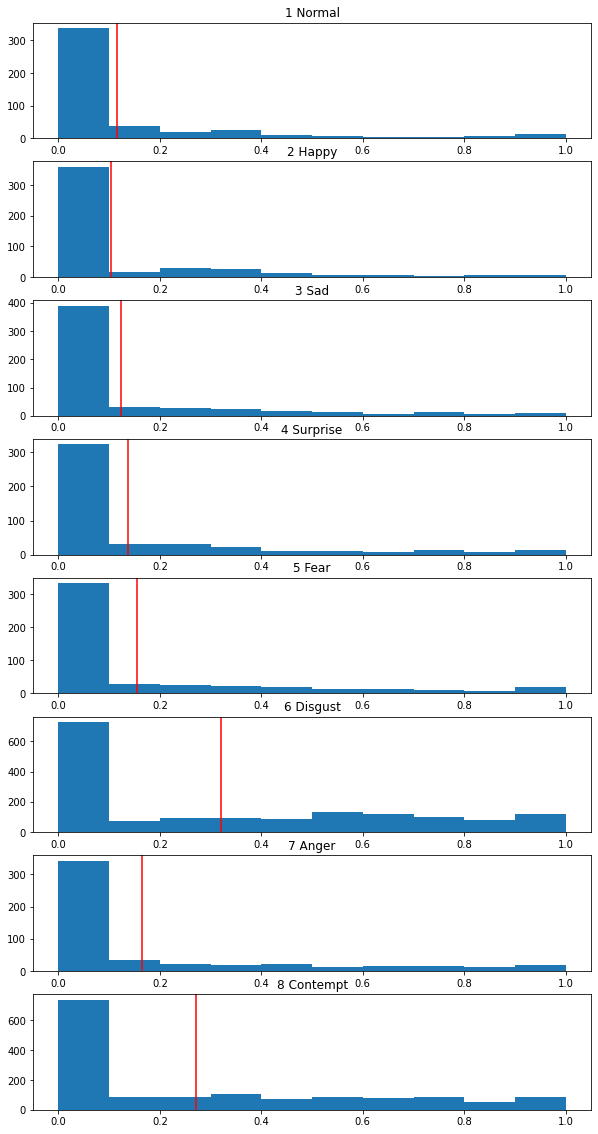

In [18]:
fig, ax = plt.subplots(8,1,figsize=(10,20))
for i in range(len(classes)):
    label = classes[i]
    sel = [row['paramoji_c'] for row in data if row['name']==label]
    ax[i].hist(sel)
    ax[i].set_title(f"{i+1} {label}")
    x=np.mean(sel)
    ax[i].axvline(x, color='red')